# Final Homework — Introduction to Data Science
## Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection
### Dataset: UCI Air Quality

# 1. Dataset Selection

The selected dataset is the **UCI Air Quality dataset** (Saverio Vito, DOI: 10.24432/C59K5F). It contains hourly averaged measurements recorded from March 2004 to February 2005 by an air-quality multisensor device placed at road level in a polluted urban area in Italy.

**Why was it collected?**  
The dataset was collected to study air-quality measurements and the behavior of a chemical multisensor system in real environmental conditions.

**Why is it suitable for this assignment?**  
After removing completely empty rows/columns, the dataset contains 9,357 observations and 15 columns. It is a real-world, mostly numerical dataset with more than 1,000 rows and 8 features and has no pre-labeled anomaly column.

| Feature | Meaning |
|---|---|
| `CO(GT)` | Carbon monoxide reference concentration |
| `PT08.S1(CO)` | Tin-oxide sensor response nominally targeted at CO |
| `NMHC(GT)` | Non-methane hydrocarbon reference concentration |
| `C6H6(GT)` | Benzene reference concentration |
| `PT08.S2(NMHC)` | Titania sensor response nominally targeted at NMHC |
| `NOx(GT)` | Nitrogen oxides reference concentration |
| `PT08.S3(NOx)` | Tungsten-oxide sensor response nominally targeted at NOx |
| `NO2(GT)` | Nitrogen dioxide reference concentration |
| `PT08.S4(NO2)` | Tungsten-oxide sensor response nominally targeted at NO2 |
| `PT08.S5(O3)` | Indium-oxide sensor response nominally targeted at O3 |
| `T` | Temperature (°C) |
| `RH` | Relative humidity (%) |
| `AH` | Absolute humidity |

`Date` and `Time` identify the measurement time and are not used as numerical modeling features.

**Limitations and possible biases.**  
The data come from one monitoring site and approximately one year, limiting geographic and temporal generalization. The observations form a time series, so consecutive rows are not necessarily independent. The dataset documentation also notes sensor cross-sensitivity, concept drift, and sensor drift. Missing measurements are encoded by `-200`, which must not be interpreted as a physical measurement.

# 2. Exploratory Data Analysis

In [1]:
# All imports are defined once and reused throughout the notebook.
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# The CSV should be placed in the same directory as this notebook.
file_path = Path("air+quality/AirQualityUCI.csv")
if not file_path.exists():
    raise FileNotFoundError(
        "Place 'AirQualityUCI.csv' in the same folder as this notebook and run again."
    )

# The UCI file uses ';' as separator and ',' as decimal separator.
df_raw = pd.read_csv(file_path, sep=";", decimal=",")

# Remove rows and columns that are completely empty.
df = df_raw.dropna(axis=0, how="all").dropna(axis=1, how="all").copy()

print("Raw shape:", df_raw.shape)
print("After removing completely empty rows/columns:", df.shape)
display(df.head())

Raw shape: (9471, 17)
After removing completely empty rows/columns: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [2]:
# Inspect variable types before modeling.
print("Data types:")
display(df.dtypes.to_frame("dtype"))

# In this dataset, -200 represents a missing measurement rather than a real value.
df = df.replace(-200, np.nan)

# Summarize missingness to support the preprocessing decision.
missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing (%)": 100 * df.isna().mean()
}).sort_values("Missing (%)", ascending=False)

display(missing_table)

Data types:


,dtype
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


,Missing Count,Missing (%)
NMHC(GT),8443,90.231912
CO(GT),1683,17.986534
NO2(GT),1642,17.548360
NOx(GT),1639,17.516298
PT08.S2(NMHC),366,3.911510
C6H6(GT),366,3.911510
PT08.S1(CO),366,3.911510
PT08.S5(O3),366,3.911510
T,366,3.911510
PT08.S3(NOx),366,3.911510


**Missing-value decision.** `NMHC(GT)` is missing in 90.23% of the observations, so it is excluded rather than imputed. The remaining modeling features are analyzed using complete observations. This leaves 6,941 rows (74.18% of the non-empty dataset) and 12 numerical features. Complete-case deletion is transparent and avoids creating synthetic values, but it may introduce bias if the missingness is systematic.

In [3]:
# Select the 12 numerical modeling features.
# NMHC(GT) is excluded because approximately 90% of its values are missing.
features = [
    "CO(GT)", "PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)",
    "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)", "PT08.S4(NO2)",
    "PT08.S5(O3)", "T", "RH", "AH"
]

# Use the same complete-case dataset in all later analyses.
X = df[features].dropna().copy()

print("Rows after preprocessing:", len(X))
print("Number of selected numerical features:", X.shape[1])
print(f"Retained percentage of non-empty rows: {100*len(X)/len(df):.2f}%")

Rows after preprocessing: 6941
Number of selected numerical features: 12
Retained percentage of non-empty rows: 74.18%


In [4]:
# Statistical summary required for the EDA.
summary = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Std": X.std(),
    "MAD": (X - X.median()).abs().median(),
    "Min": X.min(),
    "Q1": X.quantile(0.25),
    "Q3": X.quantile(0.75),
    "Max": X.max(),
    "Skewness": X.apply(skew, nan_policy="omit"),
    "Kurtosis": X.apply(kurtosis, nan_policy="omit")
})
summary["IQR"] = summary["Q3"] - summary["Q1"]

# Twelve rows are retained because each row corresponds to one required modeling feature.
display(summary.round(3))

,Mean,Median,Std,MAD,Min,Q1,Q3,Max,Skewness,Kurtosis,IQR
CO(GT),2.182,1.900,1.441,0.900,0.100,1.100,2.900,11.900,1.339,2.618,1.800
PT08.S1(CO),1119.913,1085.000,218.734,146.000,647.000,956.000,1254.000,2040.000,0.701,0.257,298.000
C6H6(GT),10.554,8.800,7.465,4.600,0.200,4.900,14.600,63.700,1.301,2.407,9.700
PT08.S2(NMHC),958.543,931.000,264.055,188.000,390.000,760.000,1135.000,2214.000,0.510,0.033,375.000
NOx(GT),250.672,186.000,208.611,101.000,2.000,103.000,335.000,1479.000,1.643,3.152,232.000
PT08.S3(NOx),816.893,786.000,251.897,150.000,322.000,642.000,947.000,2683.000,1.179,3.175,305.000
NO2(GT),113.874,110.000,47.475,31.000,2.000,79.000,142.000,333.000,0.584,0.342,63.000
PT08.S4(NO2),1452.649,1457.000,353.302,238.000,551.000,1207.000,1683.000,2775.000,0.202,-0.071,476.000
PT08.S5(O3),1057.757,1006.000,406.510,278.000,221.000,760.000,1322.000,2523.000,0.552,-0.035,562.000
T,17.755,16.800,8.845,6.200,-1.900,11.200,23.700,44.600,0.398,-0.387,12.500


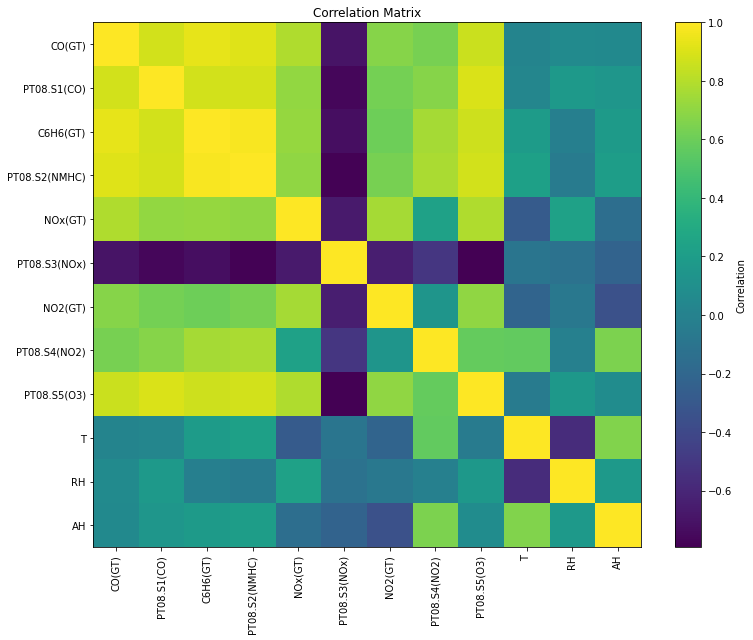

,Feature 1,Feature 2,Correlation,Absolute Correlation
21,C6H6(GT),PT08.S2(NMHC),0.983,0.983
1,CO(GT),C6H6(GT),0.930,0.930
2,CO(GT),PT08.S2(NMHC),0.914,0.914
17,PT08.S1(CO),PT08.S5(O3),0.897,0.897
12,PT08.S1(CO),PT08.S2(NMHC),0.886,0.886
11,PT08.S1(CO),C6H6(GT),0.877,0.877
0,CO(GT),PT08.S1(CO),0.877,0.877
34,PT08.S2(NMHC),PT08.S5(O3),0.877,0.877
26,C6H6(GT),PT08.S5(O3),0.861,0.861
7,CO(GT),PT08.S5(O3),0.853,0.853


In [5]:
# Correlation matrix: used to identify redundancy and relationships between variables.
corr = X.corr()

plt.figure(figsize=(11, 9))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Show only the 15 strongest pairwise correlations instead of the full pair list.
pairs = []
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        pairs.append((features[i], features[j], corr.iloc[i, j]))

strong_corr = pd.DataFrame(pairs, columns=["Feature 1", "Feature 2", "Correlation"])
strong_corr["Absolute Correlation"] = strong_corr["Correlation"].abs()
display(strong_corr.sort_values("Absolute Correlation", ascending=False).head(15).round(3))

**Correlation conclusion.** The strongest relationship is between `C6H6(GT)` and `PT08.S2(NMHC)` (\(r=0.983\)). `CO(GT)` is also strongly correlated with `C6H6(GT)` (\(r=0.930\)) and `PT08.S2(NMHC)` (\(r=0.914\)). Several sensor responses are strongly correlated with one another, while `PT08.S3(NOx)` has strong negative relationships with several pollution/sensor variables. This indicates substantial redundancy and motivates PCA.

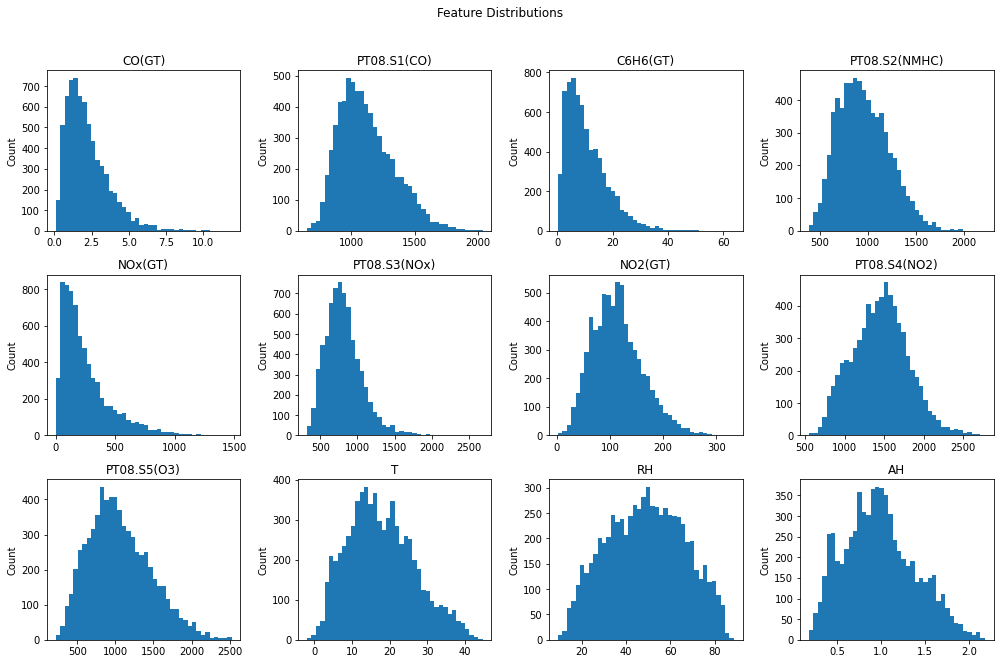

In [6]:
# Histograms for all major features, arranged compactly in one figure.
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, col in zip(axes.ravel(), features):
    ax.hist(X[col], bins=40)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
fig.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

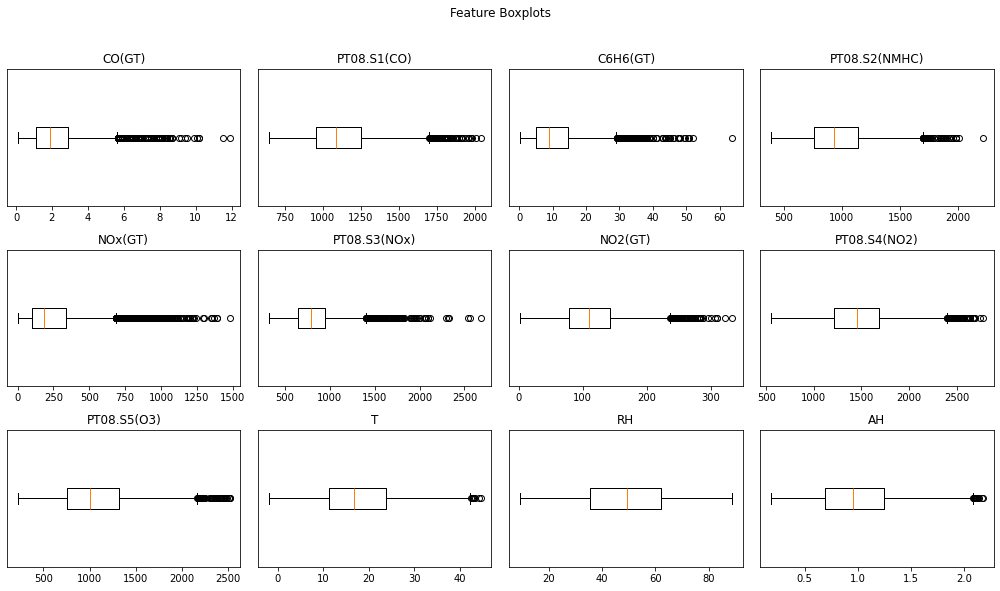

In [7]:
# Boxplots for all major features, arranged compactly in one figure.
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, col in zip(axes.ravel(), features):
    ax.boxplot(X[col].dropna(), vert=False)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Feature Boxplots", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# IQR rule: descriptive exploration of potential extreme values.
# These points are NOT removed because they may be genuine anomalies.
outlier_rows = []
for col in features:
    q1, q3 = X[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (X[col] < lower) | (X[col] > upper)

    outlier_rows.append({
        "Feature": col,
        "Potential Outliers": int(mask.sum()),
        "Percentage (%)": 100 * mask.mean()
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("Percentage (%)", ascending=False)
display(outlier_summary.round(2))

,Feature,Potential Outliers,Percentage (%)
4,NOx(GT),354,5.10
0,CO(GT),191,2.75
5,PT08.S3(NOx),182,2.62
2,C6H6(GT),160,2.31
6,NO2(GT),90,1.30
1,PT08.S1(CO),89,1.28
7,PT08.S4(NO2),58,0.84
8,PT08.S5(O3),56,0.81
3,PT08.S2(NMHC),46,0.66
11,AH,22,0.32


**Distribution and outlier conclusions.** Pollution-related variables are generally more right-skewed than the environmental variables. `NOx(GT)` is the most skewed (\(\approx1.64\)) and has the largest IQR-outlier fraction (5.10%). `CO(GT)`, `C6H6(GT)`, and `PT08.S3(NOx)` also show positive skewness/heavier tails and visible extremes. `RH` is almost symmetric and has no IQR outliers.

The extreme observations are not automatically data-entry errors. In this dataset they may correspond to real pollution episodes, unusual meteorological conditions, sensor noise/drift, or measurement artifacts. Since anomaly detection is a main goal of the assignment, deleting them before analysis would remove precisely the observations we want to investigate.

# 3. Dimensionality Reduction
## 3.1 Principal Component Analysis (PCA)

PCA finds orthogonal linear combinations of the standardized variables that successively maximize variance. If \(X\) is standardized and \(\Sigma\) is its covariance matrix, the principal directions are the eigenvectors of \(\Sigma\); their eigenvalues determine the explained variance.

In [9]:
# Standardize once because PCA and later multivariate methods are scale-sensitive.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA using all components to study explained variance and loadings.
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained))],
    "Explained Variance Ratio": explained,
    "Cumulative Explained Variance": cumulative
})
display(pca_table.round(4))

n90 = np.argmax(cumulative >= 0.90) + 1
n95 = np.argmax(cumulative >= 0.95) + 1
print("Components for >=90% variance:", n90)
print("Components for >=95% variance:", n95)

,PC,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.5759,0.5759
1,PC2,0.2070,0.7829
2,PC3,0.1123,0.8953
3,PC4,0.0391,0.9344
4,PC5,0.0215,0.9560
5,PC6,0.0137,0.9696
6,PC7,0.0107,0.9804
7,PC8,0.0080,0.9884
8,PC9,0.0054,0.9937
9,PC10,0.0030,0.9968


Components for >=90% variance: 4
Components for >=95% variance: 5


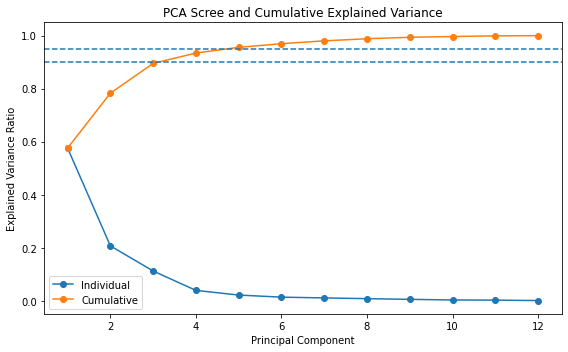

In [10]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker="o", label="Individual")
plt.plot(range(1, len(explained)+1), cumulative, marker="o", label="Cumulative")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree and Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

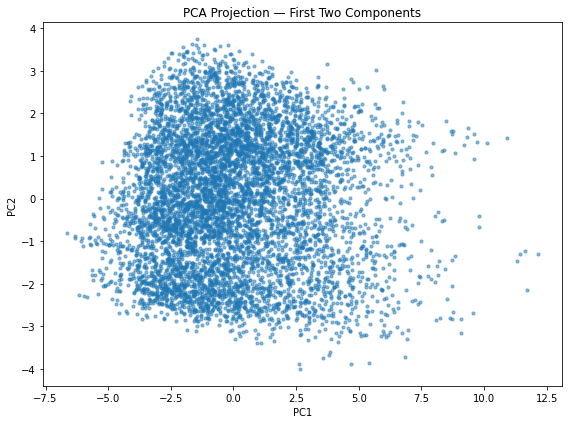

In [11]:
pca_3 = PCA(n_components=3)
X_pca3 = pca_3.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca3[:,0], X_pca3[:,1], s=10, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection — First Two Components")
plt.tight_layout()
plt.show()

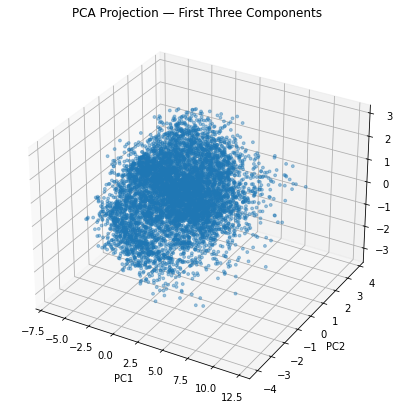

In [12]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], s=8, alpha=0.4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA Projection — First Three Components")
plt.show()

,PC1,PC2,PC3
CO(GT),0.358,-0.044,-0.036
PT08.S1(CO),0.357,-0.013,0.082
C6H6(GT),0.364,0.072,-0.062
PT08.S2(NMHC),0.369,0.087,-0.081
NOx(GT),0.306,-0.275,0.027
PT08.S3(NOx),-0.321,-0.000,-0.049
NO2(GT),0.273,-0.295,-0.291
PT08.S4(NO2),0.266,0.405,0.119
PT08.S5(O3),0.357,-0.083,0.050
T,0.037,0.582,-0.266


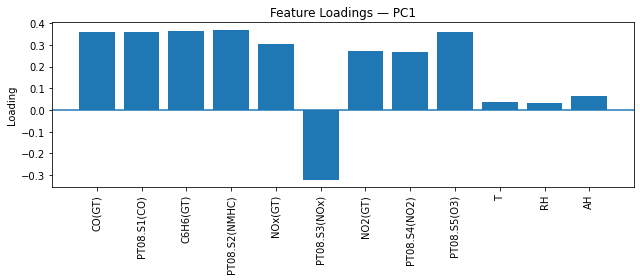

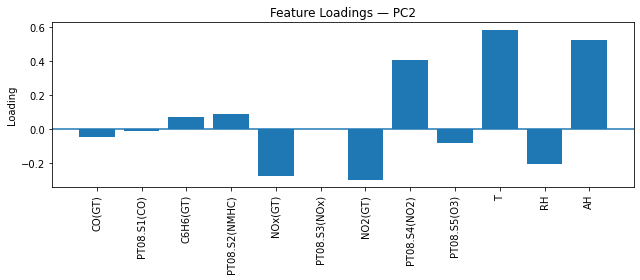

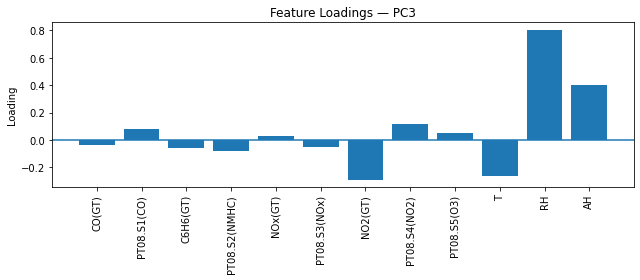

In [13]:
# Loadings quantify the contribution of each original feature to each PC.
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(len(features))]
)

# Only the three components used for interpretation/visualization are displayed.
display(loadings[["PC1", "PC2", "PC3"]].round(3))

for pc in ["PC1", "PC2", "PC3"]:
    plt.figure(figsize=(9, 4))
    plt.bar(loadings.index, loadings[pc].values)
    plt.axhline(0)
    plt.xticks(rotation=90)
    plt.ylabel("Loading")
    plt.title(f"Feature Loadings — {pc}")
    plt.tight_layout()
    plt.show()

**Question: How many principal components adequately represent the data, and how much information is lost?**  
**Answer:** Four PCs retain 93.44% of the variance, so reducing from 12 to 4 dimensions loses about **6.56%** of the total variance. Five PCs retain 95.60%, leaving only about **4.40%** unexplained. In contrast, a 2D plot retains 78.29% and a 3D plot 89.53%, so these visualizations necessarily omit some information.

**Question: Which variables are strongly correlated, and how does this affect PCA?**  
**Answer:** The EDA showed strong correlations among pollution concentrations and sensor responses, especially `C6H6(GT)`–`PT08.S2(NMHC)` (0.983), `CO(GT)`–`C6H6(GT)` (0.930), and `CO(GT)`–`PT08.S2(NMHC)` (0.914). PCA can compress this redundancy into fewer components.

**Question: What do the major PCs represent?**  
**Answer:** PC1 explains 57.59% and is dominated by the pollution/sensor variables: `PT08.S2(NMHC)`, `C6H6(GT)`, `CO(GT)`, `PT08.S5(O3)`, and `PT08.S1(CO)` have large positive loadings, while `PT08.S3(NOx)` has a large negative loading. PC1 therefore represents a broad pollution/sensor-response pattern. PC2 explains 20.70% and is driven mainly by `T`, `AH`, and `PT08.S4(NO2)`, with negative contributions from `NO2(GT)` and `NOx(GT)`, so it mainly captures an environmental/temperature-humidity contrast. PC3 explains 11.23% and is dominated by `RH`, with additional `AH` contribution, representing primarily humidity variation.

**Question: Is the reduced representation effective?**  
**Answer:** Yes for compression: only 4–5 PCs preserve most variance, confirming substantial redundancy. However, PCA is a **global linear** representation. Local neighborhoods can change after projection, clusters that overlap in 2D may separate in omitted dimensions, and rare anomalies can be hidden. PCA is computationally efficient for this dataset, but the PCs are less directly interpretable than the original physical measurements. Standardization is essential for stability with respect to measurement units; the exact components can still change if the sample or feature set changes.

# 4. Clustering Analysis

Clustering is performed on the full standardized 12-dimensional data. PCA is used only to visualize the results.

**K-Means intuition, assumptions, strengths and weaknesses.** K-Means minimizes the sum of squared Euclidean distances from observations to their assigned centroids. It works best for compact, approximately spherical clusters of comparable scale and requires \(K\) in advance. It is simple and scalable but forces every observation into a cluster and is sensitive to scaling and initialization.

**DBSCAN intuition, assumptions, strengths and weaknesses.** DBSCAN defines dense regions using a radius \(\varepsilon\) and `min_samples`. Dense connected observations form clusters; sparse observations are labeled noise. It can find irregular shapes and does not require a predefined number of clusters, but it is sensitive to \(\varepsilon\), density variation, scaling, and high-dimensional distance behavior.

**Hierarchical (Ward) intuition, assumptions, strengths and weaknesses.** Agglomerative clustering starts with individual observations and repeatedly merges groups. Ward linkage chooses the merge causing the smallest increase in within-cluster sum of squares. It provides a hierarchy and does not require centroid initialization, but a final cut must still be chosen and computation is more expensive than K-Means.

In [14]:
# Evaluate K=2,...,8. Silhouette is the main selection criterion;
# Davies-Bouldin (lower is better) and Calinski-Harabasz (higher is better)
# are included as supporting metrics.
k_results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)

    k_results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

k_results_df = pd.DataFrame(k_results)
display(k_results_df.round(3))

best_k = int(k_results_df.loc[k_results_df["Silhouette"].idxmax(), "K"])
print("Best K by silhouette:", best_k)

,K,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,51792.052,0.330,1.184,4220.304
1,3,42242.111,0.243,1.370,3371.096
2,4,36009.724,0.237,1.253,3036.193
3,5,32021.014,0.219,1.287,2776.429
4,6,29364.824,0.213,1.339,2547.166
5,7,26981.833,0.208,1.304,2411.852
6,8,24875.559,0.214,1.257,2325.870


Best K by silhouette: 2


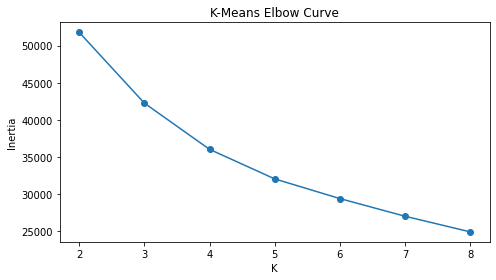

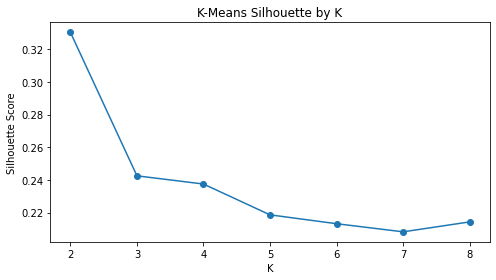

In [15]:
plt.figure(figsize=(7,4))
plt.plot(k_results_df["K"], k_results_df["Inertia"], marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(k_results_df["K"], k_results_df["Silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette by K")
plt.tight_layout()
plt.show()

Cluster sizes:


,Count
0,2481
1,4460


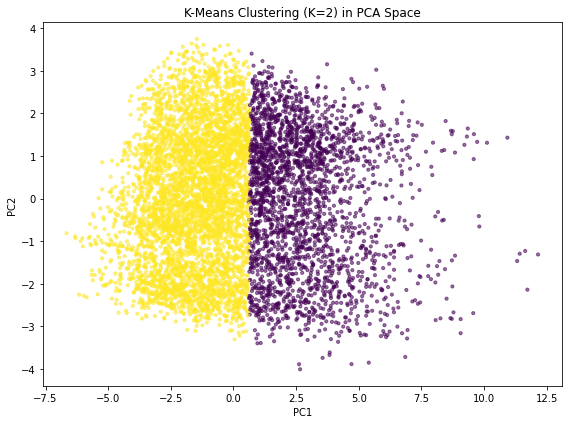

In [16]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
display(pd.Series(kmeans_labels).value_counts().sort_index().to_frame("Count"))

plt.figure(figsize=(8,6))
plt.scatter(X_pca3[:,0], X_pca3[:,1], c=kmeans_labels, s=10, alpha=0.55)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clustering (K={best_k}) in PCA Space")
plt.tight_layout()
plt.show()

In [17]:
# Interpret the K-Means clusters using the original physical units.
cluster_profile = X.copy()
cluster_profile["Cluster"] = kmeans_labels

# Means are sufficient for a compact real-world interpretation.
cluster_means = cluster_profile.groupby("Cluster").mean().T
display(cluster_means.round(2))

Cluster,0,1
CO(GT),3.67,1.36
PT08.S1(CO),1346.16,994.06
C6H6(GT),18.39,6.20
PT08.S2(NMHC),1238.47,802.83
NOx(GT),433.83,148.79
PT08.S3(NOx),600.99,937.00
NO2(GT),151.07,93.18
PT08.S4(NO2),1717.71,1305.20
PT08.S5(O3),1480.79,822.43
T,18.44,17.37


**K-Means result and real-world interpretation.** \(K=2\) has the highest silhouette score (0.330) among \(K=2,\ldots,8\). The two groups contain 2,481 and 4,460 observations. Cluster 0 has substantially higher average pollution/reference values and sensor responses: for example, mean `CO(GT)` is 3.67 versus 1.36, `NOx(GT)` is 433.83 versus 148.79, and `C6H6(GT)` is 18.39 versus 6.20. Thus Cluster 0 can be interpreted as **higher-pollution / stronger-sensor-response conditions**, while Cluster 1 represents **lower-pollution conditions**. The temperature/humidity differences are much smaller. The silhouette value is only moderate, so these should not be interpreted as two sharply separated natural populations.

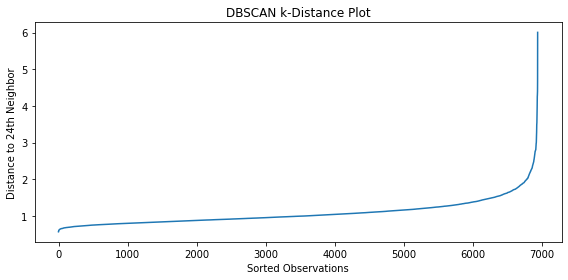

In [18]:
# k-distance plot to inspect a reasonable DBSCAN neighborhood radius.
# min_samples is set to twice the number of features as a practical starting rule.
min_samples = 2 * X_scaled.shape[1]

neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Sorted Observations")
plt.ylabel(f"Distance to {min_samples}th Neighbor")
plt.title("DBSCAN k-Distance Plot")
plt.tight_layout()
plt.show()

In [19]:
eps_candidates = [1.0, 1.5, 2.0, 2.5, 3.0]
dbscan_sensitivity = []

for eps in eps_candidates:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
    non_noise = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = 100*np.mean(labels == -1)

    sil = np.nan
    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        sil = silhouette_score(X_scaled[non_noise], labels[non_noise])

    dbscan_sensitivity.append({
        "eps": eps,
        "Clusters": n_clusters,
        "Noise (%)": noise_pct,
        "Silhouette (non-noise)": sil
    })

dbscan_sensitivity = pd.DataFrame(dbscan_sensitivity)
display(dbscan_sensitivity)

,eps,Clusters,Noise (%),Silhouette (non-noise)
0,1.0,1,22.691255,NaN
1,1.5,1,2.939058,NaN
2,2.0,1,0.446622,NaN
3,2.5,1,0.172886,NaN
4,3.0,1,0.086443,NaN


Selected eps: 2.0
Number of non-noise clusters: 1
Noise percentage: 0.45%


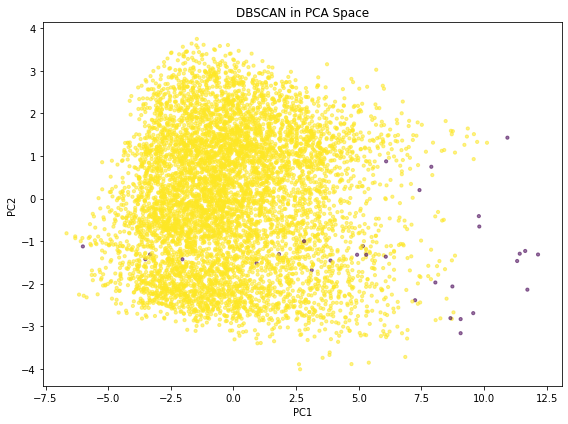

In [20]:
# eps=2.0 is used as a conservative operating point after inspecting
# the k-distance curve and the sensitivity table.
selected_eps = 2.0
dbscan = DBSCAN(eps=selected_eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_db_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print("Selected eps:", selected_eps)
print("Number of non-noise clusters:", n_db_clusters)
print(f"Noise percentage: {100*np.mean(dbscan_labels == -1):.2f}%")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca3[:, 0], X_pca3[:, 1], c=dbscan_labels, s=10, alpha=0.55)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN in PCA Space")
plt.tight_layout()
plt.show()

**DBSCAN result.** Across the tested \(\varepsilon\) values (1.0–3.0), DBSCAN consistently finds **one non-noise cluster**, while the fraction labeled as noise changes strongly from 22.69% to 0.09%. At \(\varepsilon=2.0\), 0.45% are noise. Because there is only one non-noise cluster, a silhouette score between clusters is undefined. The sensitivity of the noise fraction shows that the parameter choice matters, but the stable one-cluster result suggests that the data behave more like one connected dense cloud than several separated density regions.

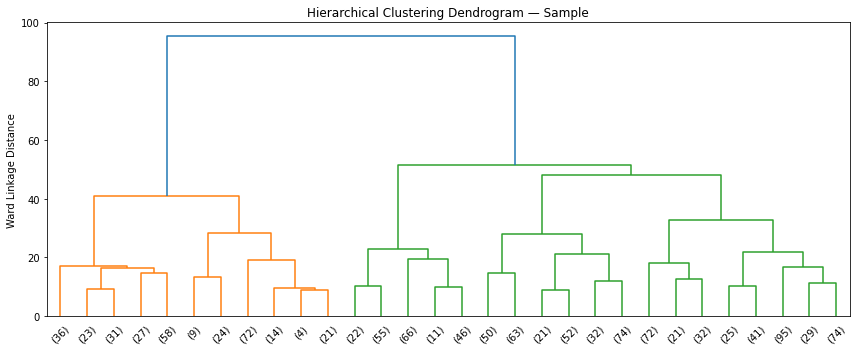

In [21]:
# A reproducible sample is used only for the dendrogram to keep it readable.
rng = np.random.default_rng(42)
sample_size = min(1200, len(X_scaled))
sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)

Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.ylabel("Ward Linkage Distance")
plt.title("Hierarchical Clustering Dendrogram — Sample")
plt.tight_layout()
plt.show()

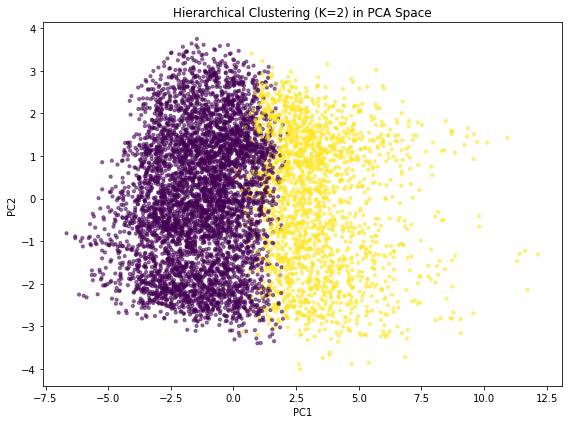

In [22]:
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hier_labels = hierarchical.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca3[:,0], X_pca3[:,1], c=hier_labels, s=10, alpha=0.55)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Hierarchical Clustering (K={best_k}) in PCA Space")
plt.tight_layout()
plt.show()

**Hierarchical result.** Ward hierarchical clustering with two clusters gives a silhouette score of 0.335, very close to K-Means (0.330), and the PCA visualization produces a similar broad partition. This agreement is expected because both K-Means and Ward favor compact groups and are related to within-cluster variance minimization.

In [23]:
# Pooled within-cluster variance: lower values indicate that observations
# are more compact within clusters than in the full standardized dataset.
def pooled_within_variance(X_array, labels, ignore_noise=False):
    labels = np.asarray(labels)

    if ignore_noise:
        valid = labels != -1
        X_array, labels = X_array[valid], labels[valid]

    total_ss, total_n = 0.0, 0
    for lab in np.unique(labels):
        group = X_array[labels == lab]
        if len(group) > 1:
            center = group.mean(axis=0)
            total_ss += ((group - center) ** 2).sum()
            total_n += group.shape[0] * group.shape[1]

    return total_ss / total_n if total_n else np.nan

global_variance = np.mean(np.var(X_scaled, axis=0))

variance_comparison = pd.DataFrame({
    "Method": ["K-Means", "DBSCAN", "Hierarchical"],
    "Within-Cluster Variance": [
        pooled_within_variance(X_scaled, kmeans_labels),
        pooled_within_variance(X_scaled, dbscan_labels, ignore_noise=True),
        pooled_within_variance(X_scaled, hier_labels)
    ]
})
variance_comparison["Global Variance"] = global_variance
variance_comparison["Within / Global"] = (
    variance_comparison["Within-Cluster Variance"] / global_variance
)
display(variance_comparison.round(3))

,Method,Within-Cluster Variance,Global Variance,Within / Global
0,K-Means,0.622,1.0,0.622
1,DBSCAN,0.975,1.0,0.975
2,Hierarchical,0.638,1.0,0.638


In [24]:
comparison_rows = []

comparison_rows.append({
    "Method": "K-Means",
    "Clusters": len(np.unique(kmeans_labels)),
    "Noise (%)": 0.0,
    "Silhouette": silhouette_score(X_scaled, kmeans_labels),
    "Davies-Bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
    "Calinski-Harabasz": calinski_harabasz_score(X_scaled, kmeans_labels)
})

valid = dbscan_labels != -1
db_n = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
db_sil = db_db = db_ch = np.nan
if db_n >= 2 and valid.sum() > db_n:
    db_sil = silhouette_score(X_scaled[valid], dbscan_labels[valid])
    db_db = davies_bouldin_score(X_scaled[valid], dbscan_labels[valid])
    db_ch = calinski_harabasz_score(X_scaled[valid], dbscan_labels[valid])

comparison_rows.append({
    "Method": "DBSCAN",
    "Clusters": db_n,
    "Noise (%)": 100*np.mean(dbscan_labels == -1),
    "Silhouette": db_sil,
    "Davies-Bouldin": db_db,
    "Calinski-Harabasz": db_ch
})

comparison_rows.append({
    "Method": "Hierarchical",
    "Clusters": len(np.unique(hier_labels)),
    "Noise (%)": 0.0,
    "Silhouette": silhouette_score(X_scaled, hier_labels),
    "Davies-Bouldin": davies_bouldin_score(X_scaled, hier_labels),
    "Calinski-Harabasz": calinski_harabasz_score(X_scaled, hier_labels)
})

display(pd.DataFrame(comparison_rows))

,Method,Clusters,Noise (%),Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,2,0.000000,0.330369,1.184367,4220.303860
1,DBSCAN,1,0.446622,NaN,NaN,NaN
2,Hierarchical,2,0.000000,0.335045,1.156176,3932.914078


**Question: Is within-cluster variance suitable here?**  
**Answer:** It is useful as a compactness measure for K-Means and Ward because both explicitly favor low within-cluster dispersion. K-Means reduces the standardized global variance from 1.0 to 0.622 and Hierarchical to 0.638. However, this metric favors methods that partition the data and is not a fair standalone evaluation of DBSCAN: DBSCAN intentionally retains one dense cluster and labels sparse points as noise, giving 0.975. Therefore silhouette, Davies–Bouldin, Calinski–Harabasz, noise fraction, PCA visualization, and method assumptions are considered together.

**Why do the algorithms disagree?** K-Means and Ward impose a partition and favor centroid/variance-based compact geometry, so both split the continuous cloud into two broad regions. DBSCAN asks instead whether there are separate density-connected regions and finds only one. This is not a contradiction; the methods define cluster structure differently. The moderate silhouette scores and DBSCAN result indicate that the data do **not** contain strongly separated natural sample clusters.

### Clustering on the Feature Space

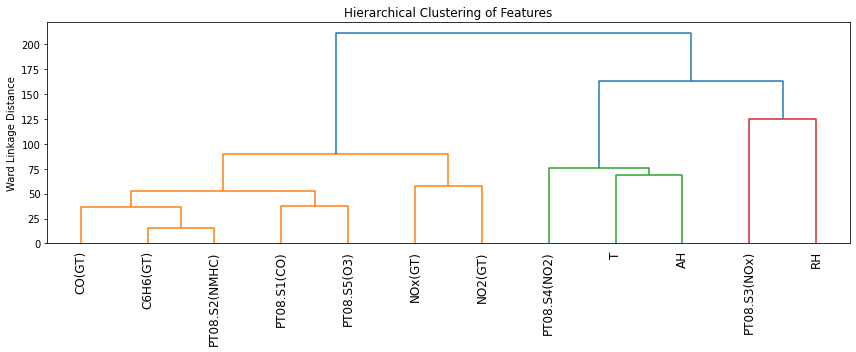

,Feature,Feature Cluster
2,C6H6(GT),1
0,CO(GT),1
6,NO2(GT),1
4,NOx(GT),1
1,PT08.S1(CO),1
3,PT08.S2(NMHC),1
8,PT08.S5(O3),1
11,AH,2
7,PT08.S4(NO2),2
9,T,2


In [25]:
# Transpose the standardized matrix: features now become the objects being clustered.
# Ward linkage groups features with similar standardized behavior across observations.
X_features = X_scaled.T
feature_Z = linkage(X_features, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(feature_Z, labels=features, leaf_rotation=90)
plt.ylabel("Ward Linkage Distance")
plt.title("Hierarchical Clustering of Features")
plt.tight_layout()
plt.show()

# Use four groups to summarize the main feature hierarchy visible in the dendrogram.
feature_cluster_labels = fcluster(feature_Z, t=4, criterion="maxclust")
feature_clusters = pd.DataFrame({
    "Feature": features,
    "Feature Cluster": feature_cluster_labels
}).sort_values(["Feature Cluster", "Feature"])

display(feature_clusters)

**Question: What information is obtained by clustering the features?**  
**Answer:** It reveals variables that vary similarly across observations and therefore may contain related or redundant information.

**Question: Were related/redundant or isolated features found?**  
**Answer:** Yes. `CO(GT)`, `C6H6(GT)`, `NOx(GT)`, `NO2(GT)`, `PT08.S1(CO)`, `PT08.S2(NMHC)`, and `PT08.S5(O3)` form one group, consistent with the strong pollution/sensor correlations found in EDA and PCA. `T`, `AH`, and `PT08.S4(NO2)` form another group. `PT08.S3(NOx)` and `RH` are each more isolated.

**Question: Did feature clustering add information beyond sample clustering?**  
**Answer:** Yes. Sample clustering showed only moderate separation between observations, whereas feature clustering exposed a clearer hierarchy of related variables and redundancy.

**Question: Where is feature clustering useful?**  
**Answer:** It is useful when many measurements may be redundant—for example sensor systems, biomedical measurements, finance, or other high-dimensional datasets—because it can reveal groups of variables that carry similar information.

# 5. Multi-Dimensional Anomaly Detection

The three required methods are applied to the same preprocessed data so that their results are comparable.

## 5.1 Z-Score Method

For feature \(j\), \(z_{ij}=(x_{ij}-\mu_j)/\sigma_j\). An observation is flagged when at least one feature has \(|z|>3\).

This method assumes that standardized distance from the mean is meaningful; the usual three-sigma interpretation is most natural for approximately Gaussian variables. Here several pollution variables are skewed/heavy-tailed, so a large Z-score can represent a legitimate pollution extreme. It is also a **feature-wise** rule: it can miss a globally unusual combination of individually ordinary values. In high dimensions, the probability that at least one feature exceeds a threshold also increases, so a simple “any feature” rule can create more false positives.

In [26]:
# Feature-wise Z-scores are exactly the absolute standardized values here.
t0 = time.perf_counter()
z_scores = np.abs(X_scaled)
z_threshold = 3.0

# A row is anomalous if any feature exceeds three standard deviations.
z_anomaly_mask = (z_scores > z_threshold).any(axis=1)
z_runtime = time.perf_counter() - t0

print("Z-score anomalies:", int(z_anomaly_mask.sum()))
print(f"Percentage: {100*z_anomaly_mask.mean():.2f}%")
print(f"Runtime: {z_runtime:.6f} seconds")

# Show which variables most often cause a three-sigma exceedance.
z_by_feature = pd.DataFrame({
    "Feature": features,
    "Extreme Observations": (z_scores > z_threshold).sum(axis=0)
})
z_by_feature["Percentage (%)"] = 100*z_by_feature["Extreme Observations"]/len(X)
display(z_by_feature.sort_values("Extreme Observations", ascending=False).round(2))

Z-score anomalies: 318
Percentage: 4.58%
Runtime: 0.001136 seconds


,Feature,Extreme Observations,Percentage (%)
4,NOx(GT),118,1.70
0,CO(GT),87,1.25
5,PT08.S3(NOx),87,1.25
2,C6H6(GT),85,1.22
1,PT08.S1(CO),41,0.59
6,NO2(GT),36,0.52
3,PT08.S2(NMHC),27,0.39
7,PT08.S4(NO2),27,0.39
8,PT08.S5(O3),27,0.39
9,T,2,0.03


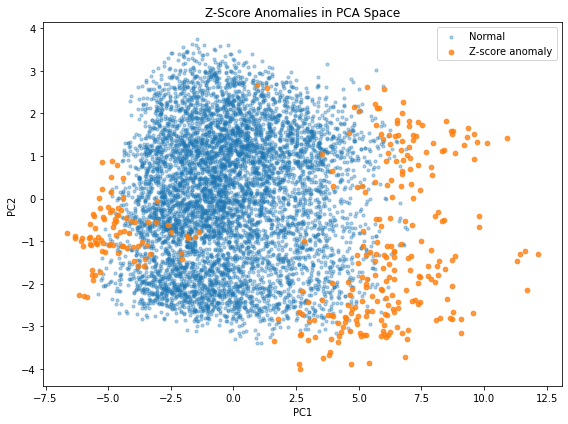

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca3[~z_anomaly_mask,0], X_pca3[~z_anomaly_mask,1],
            s=10, alpha=0.35, label="Normal")
plt.scatter(X_pca3[z_anomaly_mask,0], X_pca3[z_anomaly_mask,1],
            s=22, alpha=0.8, label="Z-score anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Z-Score Anomalies in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

**Result.** Z-score flags 318 observations (4.58%). `NOx(GT)` contributes the most feature-wise extremes (118), followed by `CO(GT)` and `PT08.S3(NOx)` (87 each) and `C6H6(GT)` (85). Because these variables are also among the more skewed/heavy-tailed features, not every flagged observation should be interpreted as faulty data.

## 5.2 Isolation Forest

Isolation Forest builds many random partitioning trees. At each node it randomly selects a feature and a split value. Anomalies tend to be isolated after fewer splits because they occupy sparse or unusual regions.

The anomaly score is based on the expected path length \(E[h(x)]\), normalized by the expected path length \(c(n)\) of a random binary search tree:

\[
s(x,n)=2^{-E[h(x)]/c(n)}.
\]

A score closer to 1 indicates easier isolation and therefore stronger anomalous behavior; lower scores indicate observations that require longer paths and look more typical. The `contamination` parameter determines the fraction ultimately labeled anomalous; it affects the decision threshold rather than providing ground truth.

Isolation Forest handles multivariate interactions and does not assume Gaussianity. It scales well compared with many distance-based methods, although interpretation is less direct and results depend on the contamination setting.

In [28]:
# Use 2% contamination as the reference operating point.
iso_contamination = 0.02

t0 = time.perf_counter()
iso = IsolationForest(
    n_estimators=300,
    contamination=iso_contamination,
    random_state=42,
    n_jobs=-1
)
iso_labels = iso.fit_predict(X_scaled)
iso_runtime = time.perf_counter() - t0

iso_anomaly_mask = iso_labels == -1

# Negating score_samples makes larger displayed values correspond to stronger anomaly.
iso_scores = -iso.score_samples(X_scaled)

print("Isolation Forest anomalies:", int(iso_anomaly_mask.sum()))
print(f"Percentage: {100*iso_anomaly_mask.mean():.2f}%")
print(f"Runtime: {iso_runtime:.6f} seconds")

Isolation Forest anomalies: 139
Percentage: 2.00%
Runtime: 0.916291 seconds


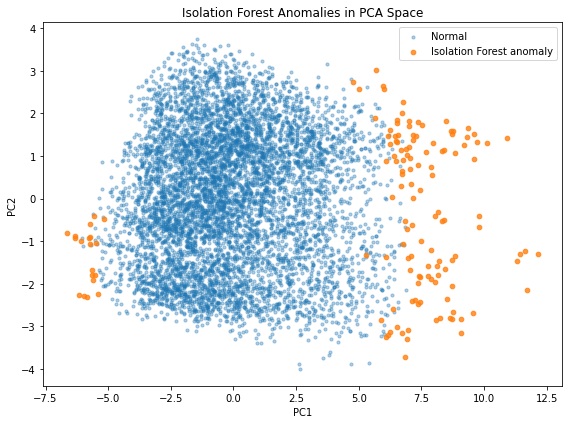

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca3[~iso_anomaly_mask,0], X_pca3[~iso_anomaly_mask,1],
            s=10, alpha=0.35, label="Normal")
plt.scatter(X_pca3[iso_anomaly_mask,0], X_pca3[iso_anomaly_mask,1],
            s=22, alpha=0.8, label="Isolation Forest anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Isolation Forest Anomalies in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

**Result.** With contamination = 0.02, Isolation Forest flags 139 observations (2.00%). The PCA visualization shows where these multivariate anomalies lie in the dominant variance projection, but the detector itself uses all 12 standardized features.

## 5.3 Local Outlier Factor (LOF)

LOF is a local density method. It compares the local reachability density of an observation with the densities of its \(k\) nearest neighbors. An LOF value around 1 means density similar to the neighborhood; values substantially above 1 indicate a point that is locally sparse and therefore more anomalous.

Unlike a global Z-score, LOF can flag a point that is not globally extreme but is unusual relative to nearby observations. Its main sensitivity is \(k\): small neighborhoods capture very local structure but can react to noise, while large neighborhoods smooth local structure. In high dimensions, nearest-neighbor distances can become less discriminative.

In [30]:
# LOF reference configuration.
lof_neighbors = 20
lof_contamination = 0.02

t0 = time.perf_counter()
lof = LocalOutlierFactor(
    n_neighbors=lof_neighbors,
    contamination=lof_contamination
)
lof_labels = lof.fit_predict(X_scaled)
lof_runtime = time.perf_counter() - t0

lof_anomaly_mask = lof_labels == -1

# sklearn stores the negative LOF; negate it so larger means more anomalous.
lof_scores = -lof.negative_outlier_factor_

print("LOF anomalies:", int(lof_anomaly_mask.sum()))
print(f"Percentage: {100*lof_anomaly_mask.mean():.2f}%")
print(f"Runtime: {lof_runtime:.6f} seconds")

LOF anomalies: 139
Percentage: 2.00%
Runtime: 0.417599 seconds


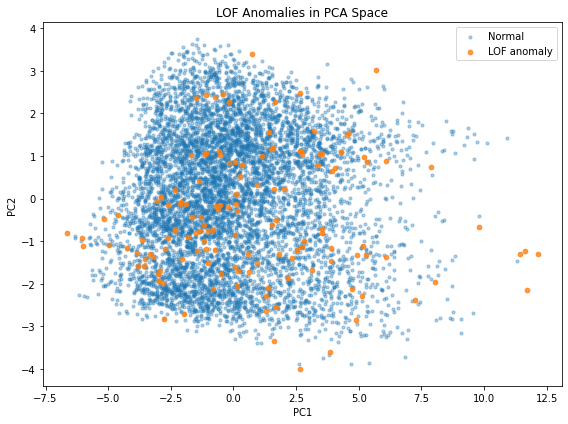

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca3[~lof_anomaly_mask,0], X_pca3[~lof_anomaly_mask,1],
            s=10, alpha=0.35, label="Normal")
plt.scatter(X_pca3[lof_anomaly_mask,0], X_pca3[lof_anomaly_mask,1],
            s=22, alpha=0.8, label="LOF anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("LOF Anomalies in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

**Result.** With \(k=20\) and contamination = 0.02, LOF flags 139 observations (2.00%). These are local-density anomalies and therefore need not coincide with the globally extreme Z-score observations.

# 6. Comparison of Anomaly Detection Methods

In [32]:
anomaly_flags = pd.DataFrame({
    "Z-score": z_anomaly_mask,
    "Isolation Forest": iso_anomaly_mask,
    "LOF": lof_anomaly_mask
}, index=X.index)

method_summary = pd.DataFrame({
    "Method": ["Z-score", "Isolation Forest", "LOF"],
    "Anomalies": anomaly_flags.sum().values,
    "Percentage (%)": 100*anomaly_flags.mean().values,
    "Runtime (s)": [z_runtime, iso_runtime, lof_runtime]
})
display(method_summary)

,Method,Anomalies,Percentage (%),Runtime (s)
0,Z-score,318,4.581472,0.001136
1,Isolation Forest,139,2.002593,0.916291
2,LOF,139,2.002593,0.417599


In [33]:
methods = list(anomaly_flags.columns)

overlap_counts = pd.DataFrame(index=methods, columns=methods, dtype=int)
jaccard = pd.DataFrame(index=methods, columns=methods, dtype=float)

for m1 in methods:
    for m2 in methods:
        inter = (anomaly_flags[m1] & anomaly_flags[m2]).sum()
        union = (anomaly_flags[m1] | anomaly_flags[m2]).sum()
        overlap_counts.loc[m1,m2] = inter
        jaccard.loc[m1,m2] = inter/union if union else np.nan

print("Pairwise overlap counts:")
display(overlap_counts)

print("Jaccard similarity:")
display(jaccard)

Pairwise overlap counts:


,Z-score,Isolation Forest,LOF
Z-score,318.0,125.0,35.0
Isolation Forest,125.0,139.0,14.0
LOF,35.0,14.0,139.0


Jaccard similarity:


,Z-score,Isolation Forest,LOF
Z-score,1.000000,0.376506,0.082938
Isolation Forest,0.376506,1.000000,0.053030
LOF,0.082938,0.053030,1.000000


In [34]:
flag_count = anomaly_flags.sum(axis=1)

agreement_summary = pd.Series({
    "Flagged by all three": int((flag_count == 3).sum()),
    "Flagged by exactly two": int((flag_count == 2).sum()),
    "Flagged by exactly one": int((flag_count == 1).sum()),
    "Flagged by none": int((flag_count == 0).sum())
})
display(agreement_summary)

Flagged by all three        13
Flagged by exactly two     135
Flagged by exactly one     287
Flagged by none           6506
dtype: int64

In [35]:
method_specific = pd.Series({
    "Z-score only": int((anomaly_flags["Z-score"] &
                         ~anomaly_flags["Isolation Forest"] &
                         ~anomaly_flags["LOF"]).sum()),
    "Isolation Forest only": int((~anomaly_flags["Z-score"] &
                                  anomaly_flags["Isolation Forest"] &
                                  ~anomaly_flags["LOF"]).sum()),
    "LOF only": int((~anomaly_flags["Z-score"] &
                     ~anomaly_flags["Isolation Forest"] &
                     anomaly_flags["LOF"]).sum())
})
display(method_specific)

Z-score only             171
Isolation Forest only     13
LOF only                 103
dtype: int64

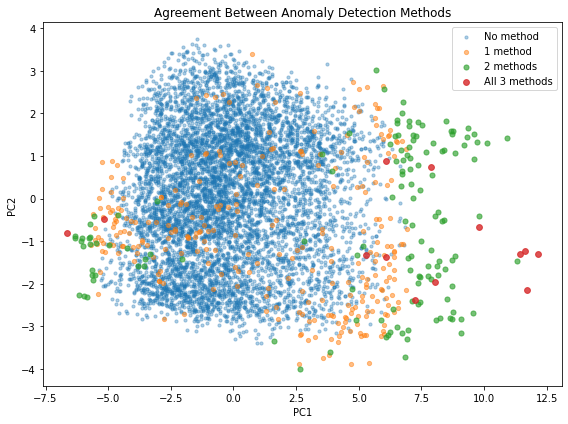

In [36]:
plt.figure(figsize=(8,6))
for count, label in [(0,"No method"), (1,"1 method"), (2,"2 methods"), (3,"All 3 methods")]:
    mask = flag_count.to_numpy() == count
    plt.scatter(
        X_pca3[mask,0], X_pca3[mask,1],
        s=10 + 8*count, alpha=0.35 + 0.15*count, label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agreement Between Anomaly Detection Methods")
plt.legend()
plt.tight_layout()
plt.show()

**Question: Which anomalies are identified by multiple methods?**  
**Answer:** Only 13 observations are flagged by all three methods. Exactly 135 are flagged by two methods. Z-score and Isolation Forest agree most strongly: they share 125 observations and have Jaccard similarity 0.377. Agreement with LOF is much lower (Jaccard 0.083 with Z-score and 0.053 with Isolation Forest).

**Question: Which anomalies are method-specific, and why?**  
**Answer:** There are 171 Z-score-only, 13 Isolation-Forest-only, and 103 LOF-only observations. Z-score emphasizes extreme individual measurements, Isolation Forest emphasizes unusual global multivariate combinations, and LOF emphasizes low local density. Their disagreement is therefore expected and illustrates that “anomaly” is definition-dependent.

**Scaling.** Z-score inherently standardizes each feature. Isolation Forest is based on random feature splits and is less directly affected by scale than Euclidean-distance methods, although the same standardized representation is used for consistency. LOF depends on distances and is strongly scale-sensitive; standardization is essential.

**Dimensionality.** Z-score does not model multivariate geometry and can produce more “any-feature” exceedances as dimensions increase. LOF is particularly vulnerable to the curse of dimensionality because neighbor distances become less informative. Isolation Forest generally handles higher-dimensional spaces better than distance-based LOF, although irrelevant dimensions can still reduce detection quality.

**Runtime and scalability.** In this run, Z-score was fastest (0.0038 s), LOF took 0.775 s, and Isolation Forest took 2.523 s. These exact times depend on hardware, but Z-score has the simplest computation. Isolation Forest is designed to scale through random subsampling/trees, whereas neighbor-based LOF becomes more costly as dataset size and dimensionality grow.

**Robustness to noise.** Z-score is sensitive to extreme values and non-Gaussian tails because means and standard deviations are affected by extremes. LOF may interpret locally sparse noise as anomalies and depends on neighborhood choice. Isolation Forest makes fewer distributional assumptions and can handle complex multivariate structure, but random partitions and contamination choice still affect the labels.

**Interpretability.** Z-score is easiest to explain because the responsible feature and number of standard deviations are explicit. LOF provides a local-density explanation but is less intuitive. Isolation Forest gives a useful anomaly score but is the least direct to explain feature-by-feature.

**False positives and false negatives in this dataset.** A false positive would label a legitimate high-pollution or unusual-weather event as a sensor/data anomaly; removing it could hide an important environmental episode. A false negative would treat a genuine sensor failure or measurement artifact as normal, potentially producing misleading air-quality conclusions. Since there are no ground-truth anomaly labels, these error rates cannot be measured directly.

### Sensitivity Analysis

In [37]:
iso_sensitivity = []
for contamination in [0.01, 0.02, 0.03, 0.05]:
    model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    labels = model.fit_predict(X_scaled)
    iso_sensitivity.append({
        "Contamination": contamination,
        "Anomalies": int((labels == -1).sum()),
        "Percentage (%)": 100*(labels == -1).mean()
    })

display(pd.DataFrame(iso_sensitivity))

,Contamination,Anomalies,Percentage (%)
0,0.01,70,1.008500
1,0.02,139,2.002593
2,0.03,209,3.011094
3,0.05,347,4.999280


In [38]:
lof_sensitivity = []
for n_neighbors in [10, 20, 35, 50]:
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=lof_contamination
    )
    labels = model.fit_predict(X_scaled)
    lof_sensitivity.append({
        "n_neighbors": n_neighbors,
        "Anomalies": int((labels == -1).sum()),
        "Percentage (%)": 100*(labels == -1).mean()
    })

display(pd.DataFrame(lof_sensitivity))

,n_neighbors,Anomalies,Percentage (%)
0,10,139,2.002593
1,20,139,2.002593
2,35,139,2.002593
3,50,139,2.002593


**Sensitivity conclusion.** Isolation Forest flags approximately the contamination fraction by design: changing contamination from 1% to 5% changes the number flagged from 70 to 347. For LOF, the number flagged remains 139 for \(k=10,20,35,50\) because contamination is fixed at 2%; therefore the count alone does **not** demonstrate stability of anomaly identity. The actual selected observations/scores can still change with \(k\), so neighborhood sensitivity remains an important limitation.

# 7. Critical Analysis and Reflection

**Question: Why is anomaly detection fundamentally difficult and ill-defined?**  
**Answer:** There is no anomaly label in this dataset and no universal definition of abnormality. A rare measurement can be an error, sensor drift, or a legitimate pollution event. The three methods demonstrate this ambiguity directly: only 13 observations are flagged by all three.

**Question: How does the curse of dimensionality affect anomaly detection?**  
**Answer:** As dimensionality grows, observations become sparse and pairwise distances tend to become less distinguishable. This makes concepts such as “nearest neighbor” less informative and particularly affects LOF and other distance/density-based methods. Irrelevant dimensions can also hide meaningful structure from multivariate detectors.

**Question: What is the difference between noise and a genuine anomaly? Give a dataset example.**  
**Answer:** Noise is an unwanted measurement disturbance or artifact, whereas a genuine anomaly is a valid but unusual event. For example, `NOx(GT)` has values up to 1479 and is the feature most frequently exceeding the Z-score threshold. Such a high reading may be a real high-pollution episode rather than a faulty measurement. Without external validation, the algorithm cannot decide this by itself.

**Question: What are the risks of assuming Gaussian data?**  
**Answer:** Several pollutant variables are positively skewed and heavy-tailed. A Gaussian-based three-sigma rule may therefore flag legitimate upper-tail pollution events too often. Conversely, anomalies that are unusual because of a multivariate combination rather than an extreme individual value can be missed by feature-wise Z-scores.

**Question: Why can PCA visualizations be misleading?**  
**Answer:** The 2D PCA projection retains 78.29% of variance and the 3D projection 89.53%, so some information is omitted. PCA preserves directions of large global variance, not necessarily rare local structures. Points that overlap in 2D may differ in omitted dimensions, and a point that looks visually extreme is not automatically anomalous in the full 12-dimensional space.

### Ethical Considerations

In this air-quality application, too many false alarms can cause analysts to ignore warnings and can lead to legitimate pollution events being discarded. More generally, anomaly detection must be used cautiously because the label “abnormal” can have real consequences.

In **surveillance**, anomaly detection can help identify unusual behavior but may also create privacy violations, biased targeting, and unfair labeling. In **medical applications**, a false positive can cause unnecessary anxiety/testing while a false negative can miss a serious condition. In **cybersecurity**, a false negative can allow a real attack to proceed, whereas excessive false positives can overwhelm analysts and disrupt legitimate activity.

Across domains, privacy, bias, fairness, and the consequences of automated labeling must be considered. Anomaly scores should therefore support human investigation rather than automatically be treated as ground truth.

## Final Conclusion

The dataset contains substantial redundancy among pollution and sensor variables: 4 PCA components retain 93.44% of the variance and 5 retain 95.60%. Sample clustering does not reveal strongly separated natural groups. K-Means and Ward Hierarchical Clustering produce similar two-group partitions, broadly corresponding to higher- versus lower-pollution conditions, but their silhouette scores are only about 0.33. DBSCAN instead finds one connected dense cluster plus a small number of noise points, supporting the interpretation of a largely continuous structure.

Anomaly detection is similarly method-dependent. Z-score flags 318 observations (4.58%), while Isolation Forest and LOF each flag 139 (2.00%) under their chosen contamination settings. Only 13 observations are shared by all three methods. The disagreement is meaningful: each method captures a different definition of abnormality, and the dataset provides no ground-truth labels for deciding that one definition is uniquely correct.